<img src='__code/__all/notebook_rules.png' width="50%"/>

In [1]:
import warnings
warnings.filterwarnings('ignore')

from __code.step2_prepare_images import Step2PrepareImages
from __code import system_v2

system_v2.System.select_working_dir(ipts="IPTS-36573")
from __code.__all import custom_style
custom_style.style()

logging file: /SNS/VENUS/shared/log/system_j35.log



# <font color='red' >Load HDF5 checkpoint from Step 1</font> -📥

Select the HDF5 file saved at the end of `step1_prepare_CCD_hdf5.ipynb` or `step1_prepare_TimePix_hdf5.ipynb`.

<font color='blue'><b>Instructions</b>: browse to the `.hdf5` checkpoint file</font>

In [2]:
o_preprocess = Step2PrepareImages(system=system_v2)
o_preprocess.select_hdf5_input_file()

logging file: /SNS/VENUS/shared/log/step2_prepare_images_j35.log


Output()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
✂️ <font color='purple' size='5'>Crop the raw data</font><font color='purple' size='3'> - OPTIONAL</font>

<font size=1 color='red'><u>Developer Notes</u>: this step will update the dictionary <i>master_3d_data_array</i></font>

In [ ]:
o_preprocess.pre_processing_crop_settings()

execute the cropping

In [ ]:
o_preprocess.pre_processing_crop()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
🧹 <font color='purple' size='5'>Remove outliers</font><font color='purple' size='3'> - OPTIONAL</font>

Three algorithms are provided:

* using `in-house` method with histogram (remove dead pixels and abnormal very high counts)
* using Tomopy `remove_outlier` method (remove high intensity bright spots)
* using Scipy `gamma_filter` method

<font color='blue'><b>Instructions</b>: select the algorithms you want to use.

<font size=1 color='red'><u>Developer Notes</u>: this step will update the dictionary <i>master_3d_data_array</i></font>

In [6]:
o_preprocess.clean_images_settings()

The next cell will be ignored if you didn't select <b>histogram</b>. 

<font color='blue'><b>Instructions</b>: if using the <b>histogram</b> algorithm, by default, all the pixels found in the first and last bin are considered as **bad** pixels. You have the option to change those settings. </font>

In [7]:
o_preprocess.clean_images_setup()

interactive(children=(IntSlider(value=100, continuous_update=False, description='Nbr bins', layout=Layout(widt…

HTML(value='<h2> Tomopy settings </h2>')

FloatSlider(value=20.0, description='Diff value', layout=Layout(width='50%'), min=1.0)

Launch the cleaning

100%|█████████████████████████████████████████████| 3/3 [00:01<00:00,  2.01it/s]


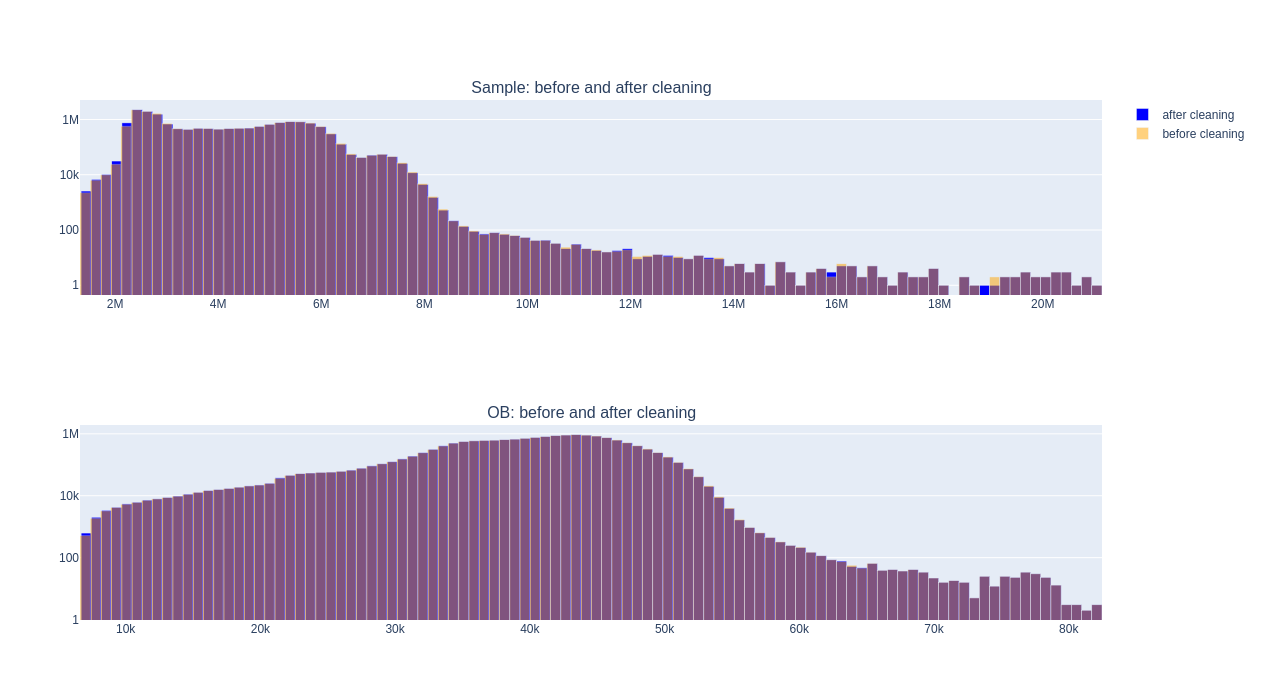

In [8]:
o_preprocess.clean_images()

<hr><hr style="border-bottom: dotted 1px;" />
👁️ <font color='purple' size='5'>Visualization</font><font color='purple' size='3'> - OPTIONAL</font>

Select the mode you want to use:
 - all images <b>(this may take a long time to process !)</b>
 - visual verification of raw, ob and dc

### How do you want to visualize the cleaned data?

In [ ]:
o_preprocess.how_to_visualize_after_cleaning()

Launch the visualization

In [ ]:
o_preprocess.visualize_cleaned_data()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
<font color='purple' size='5'>Rebin pixels</font><font color='purple' size='3'> - OPTIONAL</font>

<font size=1 color='red'><u>Developer Notes</u>: this step will update the 3d arrays <i>master_3d_data_array</i></font>

Select how you want to combine (bin) the pixels

In [ ]:
o_preprocess.rebin_settings()

Perform the binning

In [ ]:
o_preprocess.rebin_before_normalization()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
👁️ <font color='purple' size='5'>Visualize rebinned data</font><font color='purple' size='3'> - OPTIONAL</font>

In [ ]:
o_preprocess.visualization_normalization_settings()

In [ ]:
o_preprocess.visualize_rebinned_data(before_normalization=True)

<hr style="border-bottom: dotted 1px;" />
<hr style="height: 2px" />

# <font color='red'>Normalization</font> - 📉


<font color='blue'><b>Instructions</b>: in order to improve the normalization, you can turn ON/OFF any of the following 

- <font color=red><b>use beam fluctuation correction (ROI)</b></font>: that option will consider the fluctuation of the beam by matching for each projection the background region with the equivalent region of the OB. Make sure you select a region that does not contain any part of the sample.
- <font color=red><b>use sample ROI normalization</b></font>: select a region that does not contain any part of the sample and the program will make sure that this region after normalization is 1</font></i>

In [9]:
o_preprocess.normalization_settings()

This next cell will allow you to select the background region within the projections images, or will just be ignored if you not chose to use it.

<font color='blue'><b>Instructions</b>: define ROI

Make sure you select a region <font color='red'> OUTSIDE</font> of your sample

<img src="__code/__all/demo_of_roi_selection.gif" width="30%" />

NB: The next cell will be ignored if you didn't select <b>Use ROI</b></font>

In [10]:
o_preprocess.normalization_select_roi()

interactive(children=(SelectionRangeSlider(description='Left-Right:', index=(0, 20), layout=Layout(width='80%'…

This cell will perform the normalization using any of the settings you define just above.

<font size=1 color='red'><u>Developer Notes</u>: this step will create the 3d array <i>normalized_images</i></font>

In [11]:
o_preprocess.normalization()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
👁️ <font color='purple' size='5'>Visualize normalized data</font><font color='purple' size='3'> - OPTIONAL</font>

In [ ]:
o_preprocess.visualization_normalization_settings()

In [ ]:
o_preprocess.visualize_normalization()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
📤 <font color='purple' size='5'>Export the normalized data</font><font color='purple' size='3'> - OPTIONAL</font>

Select the folder where to export the normalized images


In [ ]:
o_preprocess.select_export_normalized_folder()

Run this cell to execute the export of the normalized images


In [ ]:
o_preprocess.export_normalized_images()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
<font color='purple' size='5'>Rebin pixels</font><font color='purple' size='3'> - OPTIONAL</font>

<font size=1 color='red'><u>Developer Notes</u>: this step will update the 3d array <i>normalized_images</i></font>

Select how you want to combine (bin) the pixels

In [ ]:
o_preprocess.rebin_settings()

Perform the binning

In [ ]:
o_preprocess.rebin_after_normalization()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
👁️ <font color='purple' size='5'>Visualize rebinned data</font><font color='purple' size='3'> - OPTIONAL</font>

In [ ]:
o_preprocess.visualization_normalization_settings()

In [ ]:
o_preprocess.visualize_rebinned_data()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
✂️ <font color='purple' size='5'>Crop the data</font><font color='purple' size='3'> - OPTIONAL</font>

<font size=1 color='red'><u>Developer Notes</u>: this step will update the 3d array <i>normalized_images</i></font>

In [ ]:
o_preprocess.crop_settings()

<hr style="border-bottom: dotted 1px purple;" />

execute the cropping


In [ ]:
o_preprocess.crop()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
🔄 <font color='purple' size='5'>Rotate the data</font><font color='purple' size='3'> - OPTIONAL</font>

<font color='blue'>The reconstruction algorithm will ONLY work if the rotation axis is VERTICAL</font>!

select the angle to use!

<font size=1 color='red'><u>Developer Notes</u>: this step will update the 3d array <i>normalized_images_log</i></font>

In [ ]:

o_preprocess.is_rotation_needed()

In [ ]:
o_preprocess.rotate_data_settings()

<hr style="border-bottom: dotted 1px purple;" />

Run to perform the transformation by the angle specified

In [ ]:
o_preprocess.apply_rotation()

<hr style="border-bottom: dotted 1px purple;" />

👁️ Vizualize the images after rotation - OPTIONAL

In [ ]:
o_preprocess.visualize_after_rotation()

<hr style="border-bottom: dotted 1px;" />
<hr style="height: 2px" />

# <font color='red'>Minus log conversion</font> - 📉

<font size=1 color='red'><u>Developer Notes</u>: this step will create the 3d array <i>normalized_images_log</i></font>

In [ ]:
o_preprocess.log_conversion_and_cleaning()

<hr><hr style="border-bottom: dotted 1px;" />
👁️ <font color='purple' size='3'>Visualization</font><font color='purple' size='3'> - OPTIONAL</font>


In [ ]:
o_preprocess.visualize_images_after_log()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
👁️ <font color='purple' size='5'>Visualization of sinograms</font><font color='purple' size='3'> - OPTIONAL</font>

In [ ]:
o_preprocess.visualize_sinograms()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
🧹 <font color='purple' size='5'>Remove stripes</font><font color='purple' size='3'> - OPTIONAL</font>

<font color='blue'>
You have the option here to play with various strips removal algorithms (those can caused ring artifacts during the reconstruction).<br>

<u><b>INSTRUCTIONS</b></u>

<b>1.</b> Select the region of data to use to test the algorithms<br><br>
<b>2.</b> Select 1 or any number of algorithms you want to test<br>
<b>3.</b> Define the settings for each of those algorithms selected<br>
<b>4.</b> Run the algorithms on a subset of your data<br><br>
Repeat <b>2.</b> to <b>4.</b> if needed<br><br>
Once you are happy with the result<br><br>
<b>5.</b> Select when to apply the algorithms on the full data set (<b>in</b> or <b>outside notebook</b>)
<br><font size='1px'>- <b>in notebook</b> will run the correction now and may take some time
<br>- <b>outside notebook</b> will run the correction just before the CT reconstruction, in the background [Recommended for big data sets]</font>

</font>

<font size=1 color='red'><u>Developer Notes</u>: this step will ultimately update the 3d array if in_notebook option selected <i>normalized_images_log</i></font>

#### 1. Select the region to use to test the algorithms

In [ ]:
o_preprocess.select_region_to_test_stripes_removal()

#### 2. Select the algorithms to apply

In [ ]:
o_preprocess.select_remove_strips_algorithms()

#### 3. Define the settings for each of the algorithms selected

In [ ]:
o_preprocess.define_settings()

#### 4. Run the algorithms selected and display results

In [ ]:
o_preprocess.test_algorithms_on_selected_range_of_data()

<hr style="border-bottom: dotted 1px purple;" />

DONE with the testing ?

* If not, go back to 2.
* if you are, resume the execution of the notebook!

#### 5. Select when to perform the cleaning (if any) on the full data set

In [ ]:
o_preprocess.when_to_remove_strips()

<hr style="border-bottom: dotted 1px purple;" />

If you selected **in notebook**, the strips will be removed now on the entire volume. **Please be patient** as it may takes a while to perform (depending on how many algorithm you selected)

In [ ]:
o_preprocess.remove_strips()

<hr><hr style="border-bottom: dotted 1px;" />
👁️ <font color='purple' size='3'>Visualization</font><font color='purple' size='3'> - OPTIONAL</font>

In [ ]:
o_preprocess.display_removed_strips()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
<font color='orange' size='5'>Calculate and apply tilt correction</font><font color='orange' size='3'> - OPTIONAL but RECOMMENDED</font>

The algorithm will determine the 0 and 180 degrees runs and use those to calculate the <b>tilt</b> then apply it on the volume.
<br><br>

<font color='blue'><b>Instructions</b>: first, you need to select a vertical range containing the sample

<font color='blue'>TIPS</font> - Make sure the sample is within the range defined

<font size=1 color='red'><u>Developer Notes</u>: this step will update the 3d array <i>normalized_images_log</i></font>

In [ ]:
o_preprocess.select_sample_roi()

<hr style="border-bottom: dotted 1px purple;" />

Test the calculation of the tilt

In [ ]:
o_preprocess.test_tilt_correction()

<hr>

Execute the following cell if you want to validate the tilt correction calculated. Otherwise, feel free to use the manual mode or play with the region of interest of the automatic mode.

In [ ]:
o_preprocess.validate_tilt_correction()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
<font color='orange' size='5'>Calculate center of rotation</font><font color='orange' size='3'> - OPTIONAL</font>

The algorithm will determine the 0 and 180 degrees runs and use those to calculate the <b>center of rotation</b> 

<font size=1 color='red'><u>Developer Notes</u>: this step will use the 3d array <i>normalized_images_log</i></font>

In [ ]:
o_preprocess.center_of_rotation_settings()

<hr style="border-bottom: dotted 1px purple;" />

Select the mode you want to use to calculate the **center of rotation**

* **automatic mode** will use the [algotom](https://algotom.github.io) library
* **manual mode** will let you figure out the center of rotation

<font color=red>NB</font>: if you selected **automatic mode**, first, you will need to select the 180 or 360 degrees mode to use to estimate the center of rotation.

In [ ]:
o_preprocess.run_center_of_rotation()

In [ ]:
o_preprocess.run_center_of_rotation_or_skip_it()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
<font color='purple' size='5'>Test reconstruction</font><font color='purple' size='3'> - OPTIONAL</font>

<b>Select a couple of slices to use to reconstruct</b>. 

This will allow to test:
- the calculation of the center of rotation
- tilt angle value
- cleaning of the data (outliers, stripes)
- more ...

In [ ]:
o_preprocess.select_slices_to_use_to_test_reconstruction()

<hr>

Select the algorithms you want to use in the test

In [ ]:
o_preprocess.algorithms_to_use_for_test()

<hr style="border-bottom: dotted 1px purple;" />

Perform the reconstruction on those slices

In [ ]:
o_preprocess.run_reconstruction_of_slices_to_test()

<hr style="border-bottom: dotted 1px;" /><hr style="height: 2px" />

# <font color='red'>Select reconstruction method(s)</font> - 🤔

In [ ]:
o_preprocess.select_reconstruction_method()

# <font color='red'>Set up reconstruction parameters</font> - 🤔

📋 <font color='blue'><b>Instructions</b>: 

- define the reconstruction settings (keeping the <b>default values</b> is a good choice for novice users)</font>


In [ ]:
o_preprocess.reconstruction_settings()

# <font color='red'>Create config file and export pre-processed images</font> - 📤

**Files exported**:
* <b>config file</b> will be used in the next step (step1_####.json)
* <b>log file</b> to check the full process up to here
* <b>HDF5 file containing stack of projections ready to be reconstructed, list of angles, ...</b>

In [ ]:
o_preprocess.select_export_extra_files()

<hr style="border-bottom: dotted 1px purple;" />

<hr style="border-bottom: dotted 1px;" /><hr>